# 1. Package and Data Import

In [132]:
# Package Importation
import os
import pandas as pd
import numpy as np 
import skimpy as skim
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

import sklearn.preprocessing as pre
import sklearn.cluster as clu
import sklearn.metrics as met
import sklearn.mixture as mix
import sklearn.model_selection as modsel
import sklearn.ensemble as ens
import plotly.express as px


from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

In [93]:
import warnings
warnings.filterwarnings('ignore')

In [94]:
data_origin = pd.read_csv('../data/CovidCases.csv')
data = data_origin.copy()
df = data_origin.copy()
data.head()

,ID,Country,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation
0,1,Yemen,9369,1778.0,5921,1670,306,58.0,265253.0,8651.0,30660443
1,2,Vietnam,839662,20555.0,782199,36908,8529,209.0,42517091.0,431850.0,98453377
2,3,Uzbekistan,178637,1271.0,174213,3153,5241,37.0,1377915.0,40425.0,34086135
3,4,UAE,737890,2114.0,731295,4481,73477,211.0,87246490.0,8687776.0,10042442
4,5,Turkey,7444552,66180.0,6893476,484896,87077,774.0,89847975.0,1050928.0,85493959


# 2. Descriptive Analysis

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     49 non-null     int64  
 1   Country                49 non-null     object 
 2   TotalCases             49 non-null     int64  
 3   TotalDeaths            48 non-null     float64
 4   TotalRecovered         49 non-null     int64  
 5   ActiveCases            49 non-null     int64  
 6   TotalCasesPerMillion   49 non-null     int64  
 7   TotalDeathsPerMillion  48 non-null     float64
 8   TotalTests             48 non-null     float64
 9   TotalTestsPerMillion   48 non-null     float64
 10  TotalPopulation        49 non-null     int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 4.3+ KB


In [96]:
data['check_casesPermillion'] = np.round((data['TotalCases'] /data['TotalPopulation']) * 10**6)
data['check_casesPermillion'] == data['TotalCasesPerMillion']

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
26    True
27    True
28    True
29    True
30    True
31    True
32    True
33    True
34    True
35    True
36    True
37    True
38    True
39    True
40    True
41    True
42    True
43    True
44    True
45    True
46    True
47    True
48    True
dtype: bool

In [97]:
vars = data[['Country','TotalPopulation', 'TotalTests', 'ActiveCases',
             'TotalCases', 'TotalDeaths', 'TotalRecovered']]
vars.head()

,Country,TotalPopulation,TotalTests,ActiveCases,TotalCases,TotalDeaths,TotalRecovered
0,Yemen,30660443,265253.0,1670,9369,1778.0,5921
1,Vietnam,98453377,42517091.0,36908,839662,20555.0,782199
2,Uzbekistan,34086135,1377915.0,3153,178637,1271.0,174213
3,UAE,10042442,87246490.0,4481,737890,2114.0,731295
4,Turkey,85493959,89847975.0,484896,7444552,66180.0,6893476


In [98]:
vars['TotalCases'] == vars['TotalDeaths'] + vars['TotalRecovered'] + vars['ActiveCases']

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24    False
25     True
26     True
27     True
28     True
29     True
30     True
31     True
32     True
33     True
34     True
35     True
36     True
37     True
38     True
39     True
40     True
41     True
42     True
43     True
44     True
45     True
46     True
47     True
48     True
dtype: bool

In [99]:
vars.isna().any()

Country            False
TotalPopulation    False
TotalTests          True
ActiveCases        False
TotalCases         False
TotalDeaths         True
TotalRecovered     False
dtype: bool

In [100]:
vars[vars.isna().any(axis=1)]

,Country,TotalPopulation,TotalTests,ActiveCases,TotalCases,TotalDeaths,TotalRecovered
7,Tajikistan,9809760,NaN,0,17084,124.0,16960
24,Macao,660595,4951.0,13,77,NaN,64


In [101]:
vars['TotalDeaths'] = vars['TotalDeaths'].fillna(0)
vars[vars.isna().any(axis=1)]

,Country,TotalPopulation,TotalTests,ActiveCases,TotalCases,TotalDeaths,TotalRecovered
7,Tajikistan,9809760,NaN,0,17084,124.0,16960


In [102]:
vars.describe()

,TotalPopulation,TotalTests,ActiveCases,TotalCases,TotalDeaths,TotalRecovered
count,4.900000e+01,4.800000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01
mean,9.495127e+07,2.952919e+07,41393.000000,1.574671e+06,23248.591837,1.510029e+06
std,2.818387e+08,8.651915e+07,89902.688282,4.943437e+06,68215.719677,4.829174e+06
min,4.428110e+05,4.951000e+03,0.000000,7.700000e+01,0.000000,6.400000e+01
25%,5.252032e+06,2.334699e+06,1670.000000,1.150680e+05,1271.000000,9.107400e+04
50%,1.701328e+07,7.978141e+06,14787.000000,4.120790e+05,4636.000000,3.913590e+05
75%,5.132540e+07,2.510008e+07,29242.000000,9.056410e+05,17751.000000,8.474560e+05
max,1.439324e+09,5.836315e+08,484896.000000,3.397161e+07,450814.000000,3.329348e+07


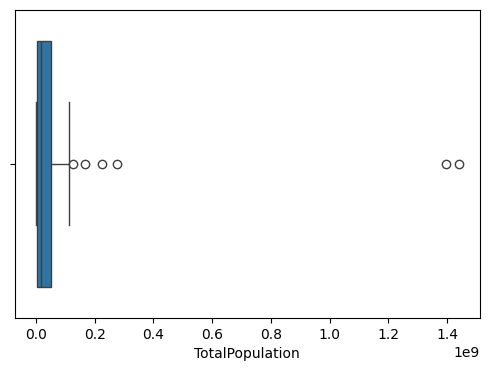

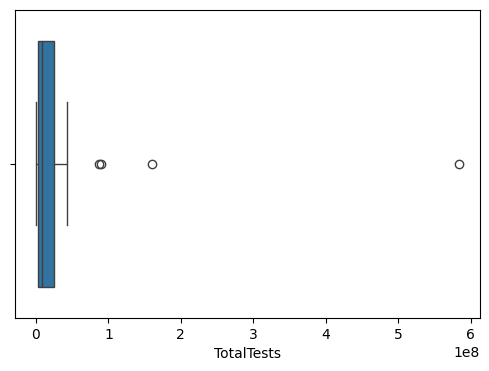

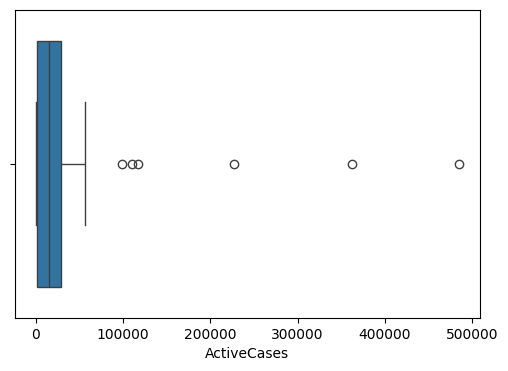

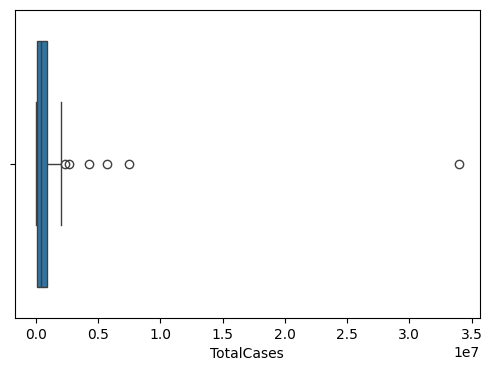

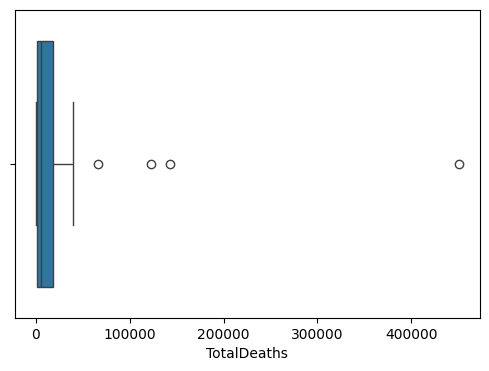

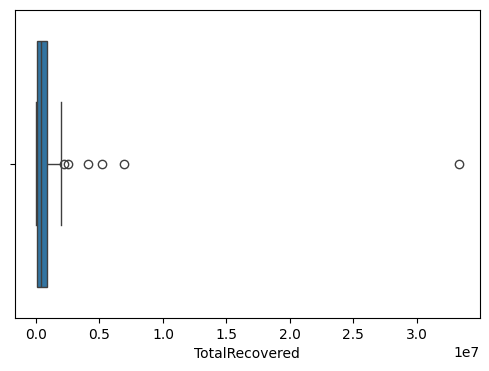

In [103]:
for col in vars.columns:
    if col != 'Country':
        plt.figure(figsize=(6, 4))
        sns.boxplot(data, x=col)

# 3. Statistic Exploratory Analysis

## 2.1 Analyse Univariée

In [104]:
print("Résumé statistique des variables numériques :")
df.describe()
print("Répartition des pays :")
print(df['Country'].value_counts())

Résumé statistique des variables numériques :
Répartition des pays :
Country
Yemen           1
Vietnam         1
Uzbekistan      1
UAE             1
Turkey          1
Timor-Leste     1
Thailand        1
Tajikistan      1
Taiwan          1
Syria           1
Sri Lanka       1
Singapore       1
Saudi Arabia    1
S. Korea        1
Qatar           1
Philippines     1
Palestine       1
Pakistan        1
Oman            1
Nepal           1
Myanmar         1
Mongolia        1
Maldives        1
Malaysia        1
Macao           1
Lebanon         1
Laos            1
Kyrgyzstan      1
Kuwait          1
Kazakhstan      1
Jordan          1
Japan           1
Israel          1
Iraq            1
Iran            1
Indonesia       1
India           1
Hong Kong       1
Georgia         1
Cyprus          1
China           1
Cambodia        1
Brunei          1
Bhutan          1
Bangladesh      1
Bahrain         1
Azerbaijan      1
Armenia         1
Afghanistan     1
Name: count, dtype: int64


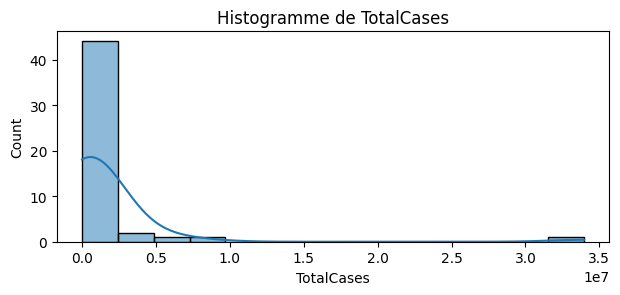

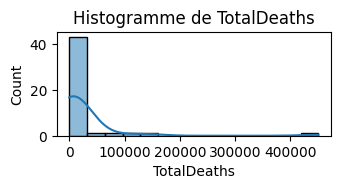

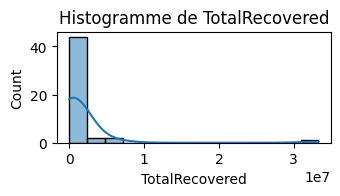

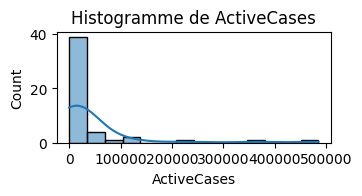

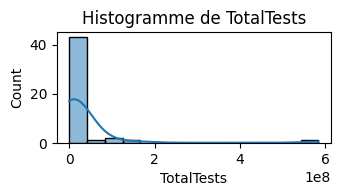

In [105]:
var_quanti = ['TotalCases','TotalDeaths', 'TotalRecovered',
              'ActiveCases', 'TotalTests']

plt.figure(figsize=(12, 8))
for i, var in enumerate(var_quanti, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f'Histogramme de {var}')  
    plt.tight_layout()
    plt.show()

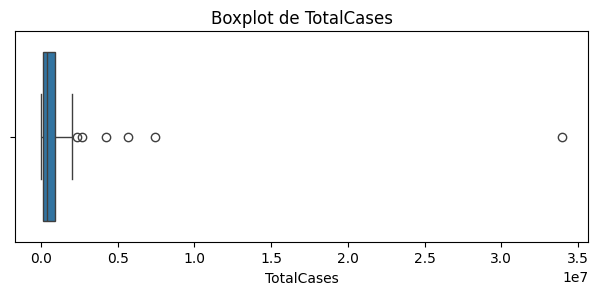

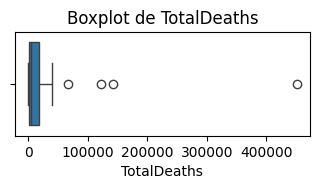

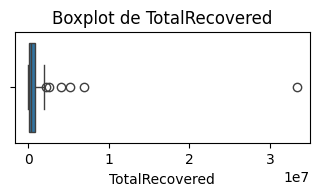

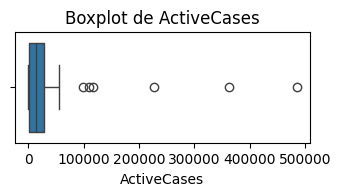

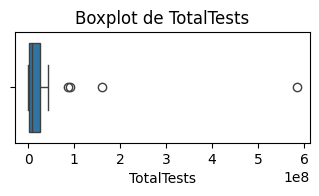

In [106]:
var_quanti = ['TotalCases','TotalDeaths', 'TotalRecovered',
              'ActiveCases', 'TotalTests',]
# ADistribution
plt.figure(figsize=(12, 8))
for i, var in enumerate(var_quanti, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot de {var}')
    plt.tight_layout()
    plt.show()

In [107]:
anomalies_summary = {}
for var in var_quanti:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    anomalies = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    anomalies_summary[var] = {'Nombre d\'anomalies': anomalies.shape[0],
                              'Pays anomalies': anomalies['Country'].tolist(),
                              'Valeurs extrêmes': anomalies[var].tolist()}
    
anomalies_df = pd.DataFrame.from_dict(anomalies_summary,orient='index')
anomalies_df

,Nombre d'anomalies,Pays anomalies,Valeurs extrêmes
TotalCases,6,"[Turkey, Philippines, Malaysia, Iran, Indonesi...","[7444552, 2674814, 2339594, 5702890, 4227932, ..."
TotalDeaths,4,"[Turkey, Iran, Indonesia, India]","[66180.0, 122592.0, 142651.0, 450814.0]"
TotalRecovered,6,"[Turkey, Philippines, Malaysia, Iran, Indonesi...","[6893476, 2536260, 2195669, 5217999, 4060851, ..."
ActiveCases,6,"[Turkey, Thailand, Philippines, Malaysia, Iran...","[484896, 110265, 98894, 116596, 362299, 227315]"
TotalTests,4,"[UAE, Turkey, India, China]","[87246490.0, 89847975.0, 583631490.0, 16000000..."


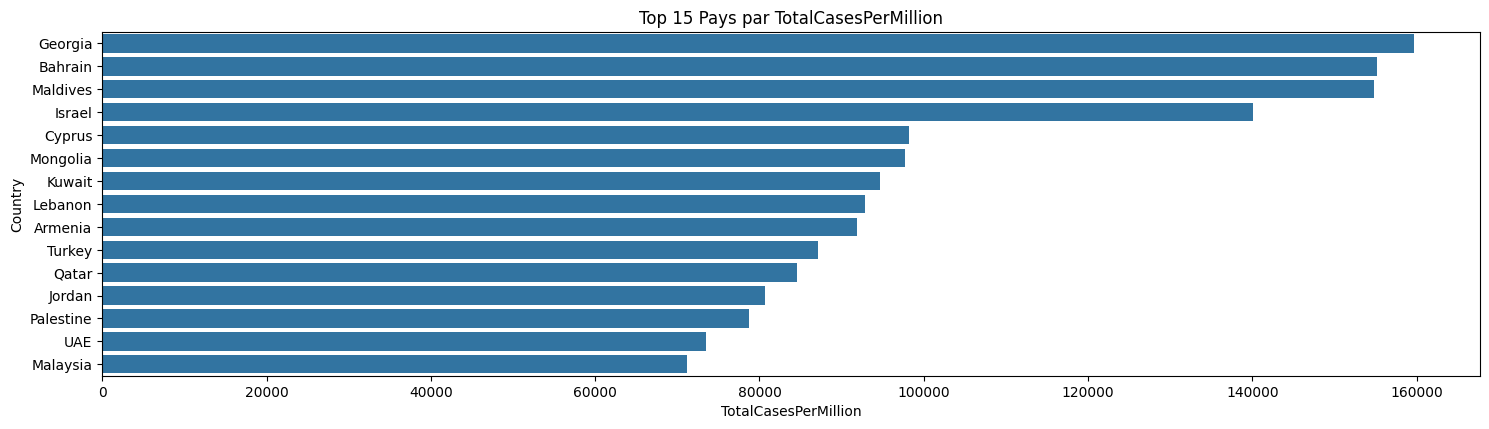

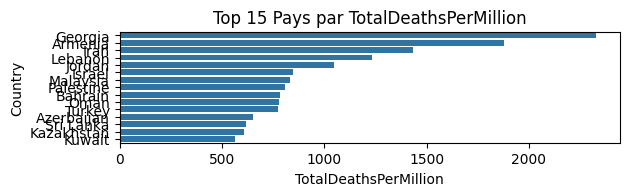

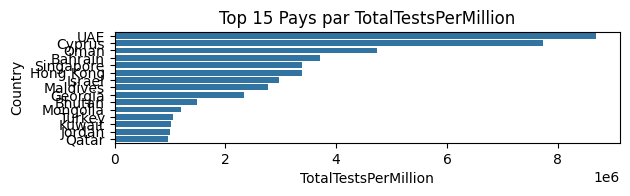

In [108]:
permillion_vars = ['TotalCasesPerMillion', 'TotalDeathsPerMillion',
                   'TotalTestsPerMillion']

plt.figure(figsize=(15, 12))
for i, var in enumerate(permillion_vars, 1):
    plt.subplot(3, 1, i)
    sorted_data = df.sort_values(by=var, ascending=False)
    sns.barplot(x=var, y='Country', data=sorted_data.head(15))
    plt.title(f'Top 15 Pays par {var}')
    plt.tight_layout()
    plt.show()

## 2.2. Multivariate Analysis

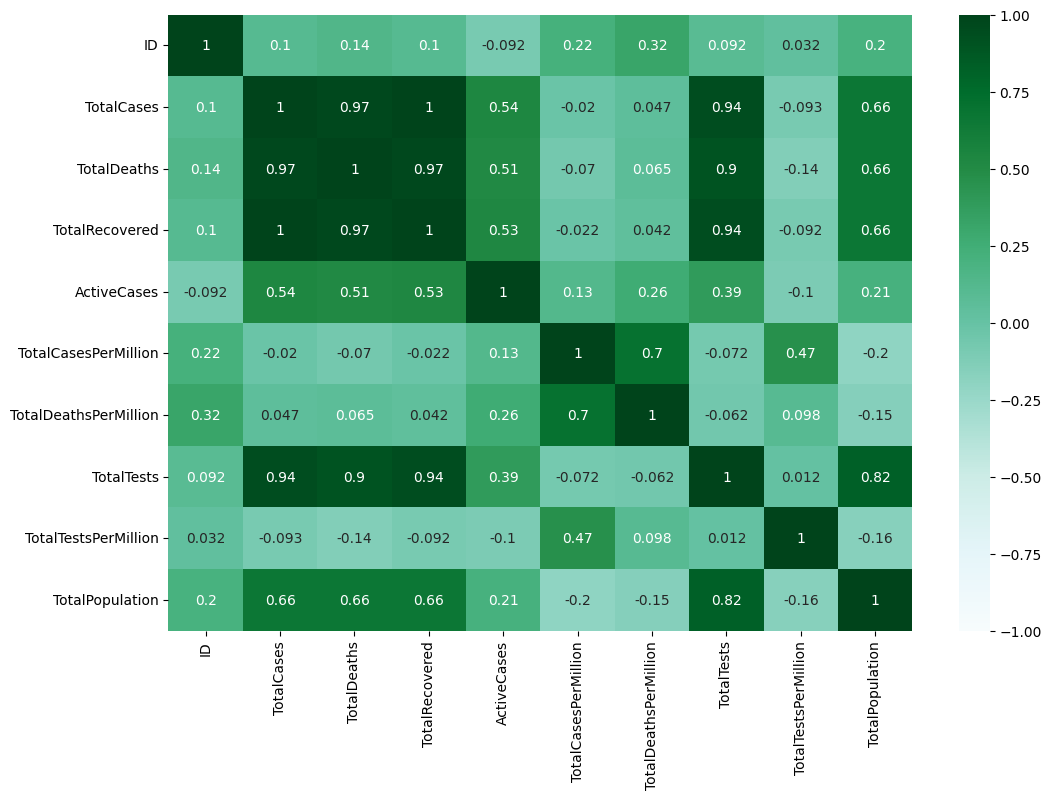

In [109]:
df_quant = df.drop(columns='Country')
plt.figure(figsize=(12,8))
sns.heatmap(df_quant.corr(method ='pearson'),vmax =1,vmin=-1,
annot=True, cmap = "BuGn")
plt.show()

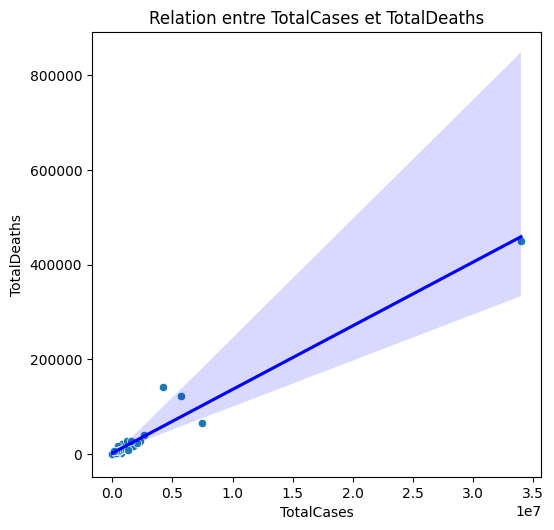

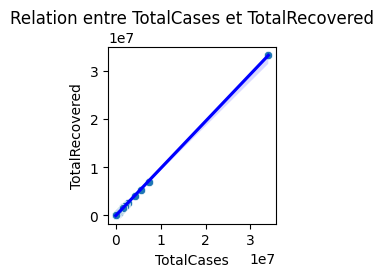

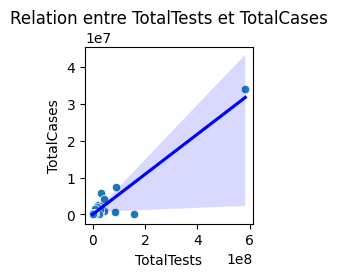

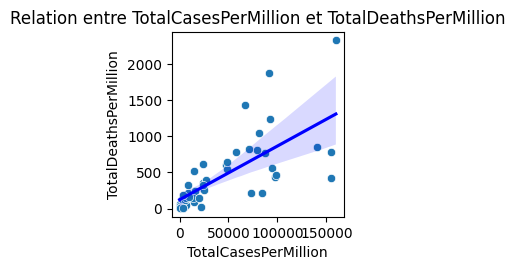

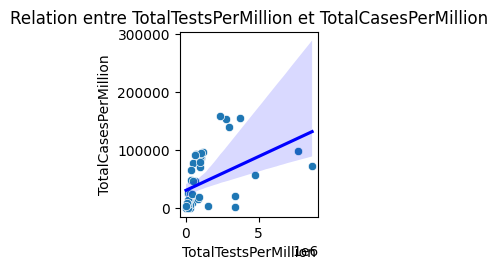

In [110]:
relations_to_explore = [('TotalCases', 'TotalDeaths'),
                        ('TotalCases', 'TotalRecovered'),
                        ('TotalTests', 'TotalCases'),
                        ('TotalCasesPerMillion', 'TotalDeathsPerMillion'),
                        ('TotalTestsPerMillion', 'TotalCasesPerMillion')]

plt.figure(figsize=(15, 10))
for i, (x, y) in enumerate(relations_to_explore, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[x], y=df[y])
    sns.regplot(x=df[x], y=df[y], scatter=False, color='blue')
    plt.title(f'Relation entre {x} et {y}')
    plt.tight_layout()
    plt.show()

# 3. Definition of KPIs

In [111]:
data_pm = pd.DataFrame(vars)
pmindicators = pd.DataFrame()
pmindicators['Country'] = vars['Country']
# List of variables to transform
variables = ["TotalTests", "ActiveCases", "TotalCases", "TotalDeaths",
"TotalRecovered"]

# Compute per million values
for var in variables:
    data_pm [f"{var}PerMillion"] = np.round(data_pm [var] / data_pm["TotalPopulation"] * 10**6)
    pmindicators [f"{var}PerMillion"] = np.round(vars[var] /vars["TotalPopulation"] * 10**6)

In [112]:
data_pm['Mortality Rate'] = data_pm['TotalDeaths'] /data_pm['TotalCases'] * 100
data_pm['Recovery Rate'] = data_pm['TotalRecovered'] /data_pm['TotalCases'] * 100
data_pm['Active Case Rate'] = data_pm['ActiveCases'] /data_pm['TotalCases'] * 100
data_pm['Testing Efficiency'] = data_pm['TotalTests'] /data_pm['TotalCases'] * 100

data_pm

pmindicators['MortalityRate'] = data_pm['TotalDeaths'] /data_pm['TotalCases'] * 100
pmindicators['RecoveryRate'] = data_pm['TotalRecovered'] /data_pm['TotalCases'] * 100
pmindicators['ActiveCaseRate'] = data_pm['ActiveCases'] /data_pm['TotalCases'] * 100
pmindicators['TestingEfficiency'] = data_pm['TotalTests'] /data_pm['TotalCases'] * 100
pm5_ratios4 = pmindicators.copy()

# 4. Analysis over Ratios and Indicators

In [113]:
categorical_col = "Country"
numerical_cols = data_pm.select_dtypes(include=["number"]).columns

def vizualise_top_bottom(data_pm, numerical_cols, categorical_col ="Country"):
    for col in numerical_cols:
        top_10 = data_pm.groupby(categorical_col)[col].mean().nlargest(10)
        bottom_10 = data_pm.groupby(categorical_col)[col].mean().nsmallest(10)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        top_10.sort_values().plot(kind="barh", color="skyblue",
        edgecolor="black", ax=axes[0])
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Country")
        axes[0].set_title(f"Top 10 Countries with Highest {col}")
        axes[0].grid(axis="x", linestyle="--", alpha=0.7)
        bottom_10.sort_values().plot(kind="barh", color="salmon",
        edgecolor="black", ax=axes[1])
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Country")
        axes[1].set_title(f"Bottom 10 Countries with Lowest {col}")
        axes[1].grid(axis="x", linestyle="--", alpha=0.7)
        min_val = min(top_10.min(), bottom_10.min())
        max_val = max(top_10.max(), bottom_10.max())
        axes[0].set_xlim(min_val, max_val)
        axes[1].set_xlim(min_val, max_val)
        plt.tight_layout()
        plt.show()
        vizualise_top_bottom(pm5_ratios4,pm5_ratios4.select_dtypes(include=["number"]).columns)

# 5. Country Categorization based on KPIs

In [114]:
median_cat = data_pm.copy()

In [115]:
# Sélection des 10 pays avec le plus grand nombre de cas par million
top_10_cases = median_cat['TotalCasesPerMillion'].nlargest(10)

median_cat['high_cases'] = median_cat['TotalCasesPerMillion'].isin(top_10_cases)
top_10_mortality = median_cat['Mortality Rate'].nlargest(10)

median_cat['high_Mortality_Rate'] = median_cat['Mortality Rate'].isin(top_10_mortality)
top_10_recovery = median_cat['Recovery Rate'].nlargest(10)

median_cat['high_Recovery_Rate'] = median_cat['Recovery Rate'].isin(top_10_recovery)
top_10_testing = median_cat['Testing Efficiency'].nlargest(10)

median_cat['High_testing_Rate'] = median_cat['Testing Efficiency'].isin(top_10_testing)

# Sélection des 10 pays avec le moins de cas par million
bottom_10_cases = median_cat['TotalCasesPerMillion'].nsmallest(10)
median_cat['low_cases'] = median_cat['TotalCasesPerMillion'].isin(bottom_10_cases)
bottom_10_mortality = median_cat['Mortality Rate'].nsmallest(10)
median_cat['low_Mortality_Rate'] = median_cat['Mortality Rate'].isin(bottom_10_mortality)
bottom_10_recovery = median_cat['Recovery Rate'].nsmallest(10)
median_cat['low_Recovery_Rate'] = median_cat['Recovery Rate'].isin(bottom_10_recovery)
bottom_10_testing = median_cat['Testing Efficiency'].nsmallest(10)

median_cat['low_testing_Rate'] = median_cat['Testing Efficiency'].isin(bottom_10_testing)
median_cat['BestCountries'] = ~median_cat['high_Mortality_Rate'] & median_cat['High_testing_Rate'] & median_cat['high_Recovery_Rate']
median_cat['WorstCountry'] = median_cat['high_Mortality_Rate'] & ~median_cat['High_testing_Rate'] & ~median_cat['high_Recovery_Rate']

In [116]:
score_analysis = pm5_ratios4.copy()
# Normalize data
for X in score_analysis.columns:
    if X !='Country':
        score_analysis[X] = (score_analysis[X] - score_analysis[X].min())/ (score_analysis[X].max() - score_analysis[X].min())

In [117]:
score_analysis['Performance_score'] = score_analysis['RecoveryRate'] - score_analysis['MortalityRate'] - score_analysis['ActiveCaseRate'] + score_analysis['TestingEfficiency']
score_analysis['Security_score'] = score_analysis['MortalityRate'] + score_analysis['ActiveCaseRate'] - score_analysis['TestingEfficiency']
#vizualise_top_bottom(score_analysis, ['Security_score','Performance_score'])

In [119]:
score_analysis['Performance_score'] = 0.3 * score_analysis['RecoveryRate'] - 0.3 * score_analysis['MortalityRate'] - 0.2*score_analysis['ActiveCaseRate'] + 0.2*score_analysis['TestingEfficiency']
score_analysis['Security_score'] = 0.4 * score_analysis['MortalityRate'] + 0.3*score_analysis['ActiveCaseRate'] -0.3*score_analysis['TestingEfficiency']
#vizualise_top_bottom(score_analysis, ['Security_score','Performance_score'])

# 6. Data Preparation

In [120]:
missing_cols = data.columns[data.isna().sum() > 0]
missing_cols
missing_rows = data[data.isnull().any(axis=1)]
missing_rows

,ID,Country,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation,check_casesPermillion
7,8,Tajikistan,17084,124.0,16960,0,1742,13.0,NaN,NaN,9809760,1742.0
24,25,Macao,77,NaN,64,13,117,NaN,4951.0,7495.0,660595,117.0


In [121]:
mask_macao = data['Country'].str.lower() == 'macao'

data.loc[mask_macao, 'TotalDeaths'] = (data.loc[mask_macao, 'TotalCases'] - data.loc[mask_macao, 'TotalRecovered'] - data.loc[mask_macao, 'ActiveCases'])
data.loc[mask_macao, 'TotalDeathsPerMillion'] = (data.loc[mask_macao, 'TotalDeaths'] * 1000000) / data.loc[mask_macao, 'TotalPopulation']

data[data['Country'].str.lower() == 'macao']

,ID,Country,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation,check_casesPermillion
24,25,Macao,77,0.0,64,13,117,0.0,4951.0,7495.0,660595,117.0


In [123]:
df_num = data.drop(columns='Country')
imputed = KNNImputer(n_neighbors=3, weights='distance').fit_transform(df_num)
df_wo_nan = pd.DataFrame(imputed, columns=df_num.columns,index=data.index)
df_wo_nan.insert(0, 'Country', data['Country'])
missing_rows = df_wo_nan[df_wo_nan.isnull().any(axis=1)]
missing_rows

,Country,ID,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation,check_casesPermillion


In [124]:
cols_to_round = ['TotalCases', 'TotalDeaths', 'TotalRecovered','ActiveCases']
df_wo_nan[cols_to_round] =df_wo_nan[cols_to_round].round(0).astype(int)
df_wo_nan['Check_ActiveCases'] = df_wo_nan['TotalCases'] -df_wo_nan['TotalDeaths'] - df_wo_nan['TotalRecovered']
inconsistencies_active_cases = df_wo_nan[df_wo_nan['ActiveCases'] != df_wo_nan['Check_ActiveCases']]
inconsistencies_active_cases

rule_violations = df_wo_nan[(df_wo_nan['ActiveCases'] < 0) |(df_wo_nan['ActiveCases'] > df_wo_nan['TotalCases']) |(df_wo_nan['TotalCases'] < df_wo_nan['TotalDeaths'])]
rule_violations

df_wo_nan['Check_TotalCasesPerMillion'] = (df_wo_nan['TotalCases'] *1000000) / df['TotalPopulation']
df_wo_nan['Check_TotalDeathsPerMillion'] = (df_wo_nan['TotalDeaths'] *1000000) / df['TotalPopulation']
inconsistencies_cases_per_million = df_wo_nan[(abs(df_wo_nan['TotalCasesPerMillion'] -df_wo_nan['Check_TotalCasesPerMillion']) > 1) |(abs(df_wo_nan['TotalDeathsPerMillion'] -df_wo_nan['Check_TotalDeathsPerMillion']) > 1)]

df_wo_nan.drop(columns=['Check_ActiveCases','Check_TotalCasesPerMillion', 'Check_TotalDeathsPerMillion'],inplace=True)
df_wo_nan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                49 non-null     object 
 1   ID                     49 non-null     float64
 2   TotalCases             49 non-null     int64  
 3   TotalDeaths            49 non-null     int64  
 4   TotalRecovered         49 non-null     int64  
 5   ActiveCases            49 non-null     int64  
 6   TotalCasesPerMillion   49 non-null     float64
 7   TotalDeathsPerMillion  49 non-null     float64
 8   TotalTests             49 non-null     float64
 9   TotalTestsPerMillion   49 non-null     float64
 10  TotalPopulation        49 non-null     float64
 11  check_casesPermillion  49 non-null     float64
dtypes: float64(7), int64(4), object(1)
memory usage: 4.7+ KB


In [125]:
df_wo_nan_country = df_wo_nan.drop(columns='Country')
ss = pre.StandardScaler()
df_wo_nan_country_sd = ss.fit_transform(df_wo_nan_country)
df_wo_nan_country_sd1 = pd.DataFrame(df_wo_nan_country_sd,columns=df_wo_nan_country.columns,index=df_wo_nan_country.index)
df = df_wo_nan_country_sd1.copy()

In [126]:

df['MortalityRate'] = (df['TotalDeaths'] / df['TotalCases']) * 100
df['RecoveryRate'] = (df['TotalRecovered'] / df['TotalCases']) * 100
df['ActiveCaseRate'] = (df['ActiveCases'] / df['TotalCases']) * 100
df['TestingEfficiency'] = (df['TotalTests'] / df['TotalCases']) * 100
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     49 non-null     float64
 1   TotalCases             49 non-null     float64
 2   TotalDeaths            49 non-null     float64
 3   TotalRecovered         49 non-null     float64
 4   ActiveCases            49 non-null     float64
 5   TotalCasesPerMillion   49 non-null     float64
 6   TotalDeathsPerMillion  49 non-null     float64
 7   TotalTests             49 non-null     float64
 8   TotalTestsPerMillion   49 non-null     float64
 9   TotalPopulation        49 non-null     float64
 10  check_casesPermillion  49 non-null     float64
 11  MortalityRate          49 non-null     float64
 12  RecoveryRate           49 non-null     float64
 13  ActiveCaseRate         49 non-null     float64
 14  TestingEfficiency      49 non-null     float64
dtypes: float

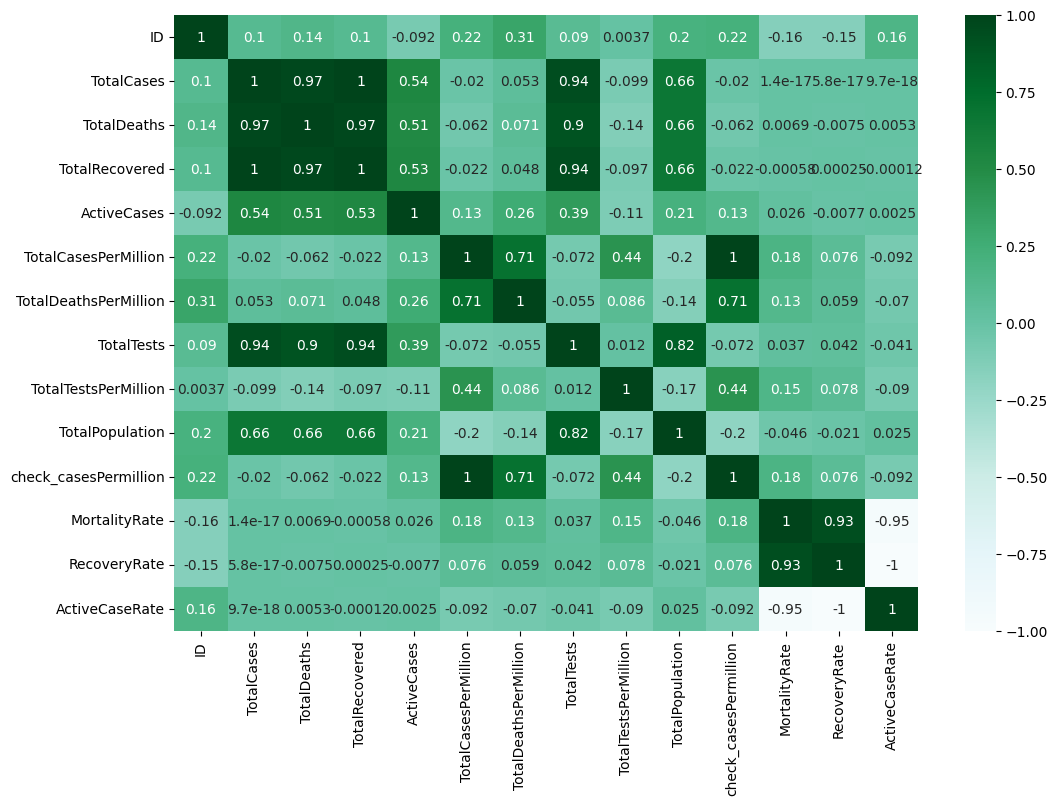

In [127]:

plt.figure(figsize=(12,8))
sns.heatmap(df.iloc[:,:-1].corr(method ='pearson'),vmax =1,vmin=-1,annot=True, cmap = "BuGn")
plt.show()

# 7. Categorization over a different methods

In [133]:
y = (
(df['TotalCases'] > df['TotalCases'].median()) &
(
(df['TotalDeaths'] > df['TotalDeaths'].median()) |
(df['TotalRecovered'] < df['TotalRecovered'].median()) |
(df['TotalTests'] < df['TotalTests'].median())
)
).astype(int)
X = df.drop(columns=
['TotalCases','TotalDeaths','TotalRecovered','TotalTests'])
X_train, X_test, y_train, y_test = modsel.train_test_split(X, y,
test_size=0.2, random_state=42)
rf_model = ens.RandomForestClassifier(n_estimators=100, max_depth=3,
random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [134]:
y_pred = rf_model.predict(X_test)
accuracy = met.accuracy_score(y_test, y_pred)
conf_matrix = met.confusion_matrix(y_test, y_pred)
class_report = met.classification_report(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Confusion Matrix:", conf_matrix)
print("Classification Report:", class_report)

Model Accuracy: 0.6
Confusion Matrix: [[4 1]
 [3 2]]
Classification Report:               precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.67      0.40      0.50         5

    accuracy                           0.60        10
   macro avg       0.62      0.60      0.58        10
weighted avg       0.62      0.60      0.58        10



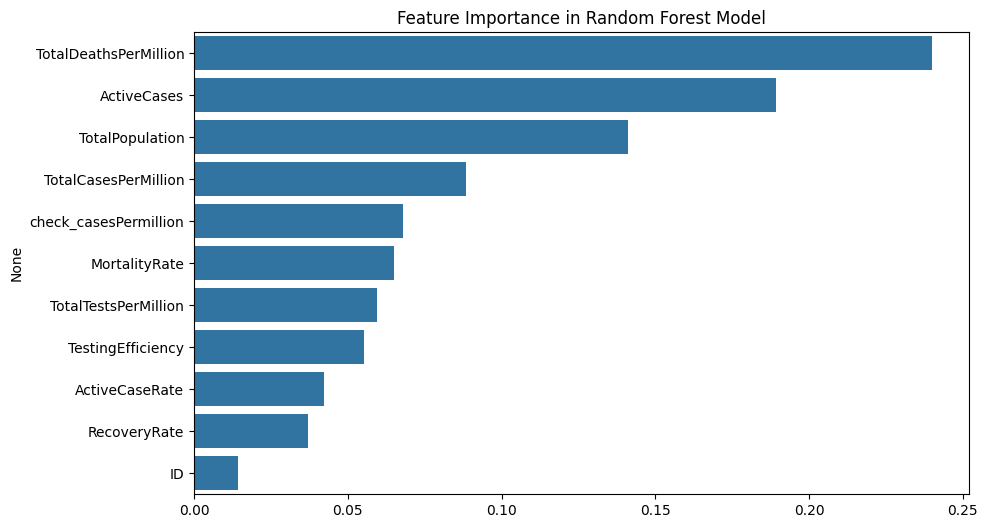

|--- check_casesPermillion <= -0.79
|   |--- class: 0.0
|--- check_casesPermillion >  -0.79
|   |--- TotalTestsPerMillion <= 1.06
|   |   |--- ActiveCases <= -0.45
|   |   |   |--- class: 0.0
|   |   |--- ActiveCases >  -0.45
|   |   |   |--- class: 1.0
|   |--- TotalTestsPerMillion >  1.06
|   |   |--- class: 0.0



In [135]:
feature_importance = pd.Series(rf_model.feature_importances_,
index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance in Random Forest Model")
plt.show()
from sklearn.tree import export_text
tree_rules = export_text(rf_model.estimators_[0],
feature_names=list(X.columns))
print(tree_rules)


In [136]:
def get_thresholds_from_forest(forest, feature_name, feature_names):
    idx = feature_names.index(feature_name)
    thresholds = []
    for tree in forest.estimators_:
        tree_thresholds = tree.tree_.threshold
        tree_features = tree.tree_.feature
        thresholds += list(tree_thresholds[tree_features == idx])
    return np.unique([t for t in thresholds if t != -2])

thresholds = get_thresholds_from_forest(rf_model, 'RecoveryRate',
list(X.columns))
print(thresholds)

indicators = ['ActiveCaseRate', 'RecoveryRate', 'MortalityRate',
'TestingEfficiency']
feature_names = list(X.columns)
for feature in indicators:
    if feature in feature_names:
        thresholds = get_thresholds_from_forest(rf_model, feature,feature_names)
        print(f"Thresholds for {feature}: {np.round(thresholds, 2)}\n")
    else:
        print(f"{feature} is not in the model features")
    average_thresholds = {}

for feature in indicators:
    if feature in feature_names:
        thresholds = get_thresholds_from_forest(rf_model, feature,feature_names)
        if len(thresholds) > 0:
            median_val = np.median(thresholds)
            average_thresholds[feature] = round(median_val, 2)
        else:
            average_thresholds[feature] = None
    else:
        average_thresholds[feature] = 'Not in feature list'
# Display result
for key, value in average_thresholds.items():
    print(f"Median threshold for {key}: {value}")

[ 92.8263855   93.51051712  94.57406616  96.21701431  97.27552414
  97.52039337  98.31809235  98.38903427  98.65779114  98.76557922
  99.24098587 100.13913345 100.18732834 100.27726364 100.60847855]
Thresholds for ActiveCaseRate: [ 41.46  44.43  45.43  54.63  59.13  88.95 119.87 146.47 147.5  147.52
 176.73 193.19 199.18 201.27 264.98 285.94]

Thresholds for RecoveryRate: [ 92.83  93.51  94.57  96.22  97.28  97.52  98.32  98.39  98.66  98.77
  99.24 100.14 100.19 100.28 100.61]

Thresholds for MortalityRate: [ 54.18  57.81  67.41  68.59  72.12  75.18  79.9   96.79  97.09 102.61
 107.59 108.54 108.65 109.94 110.44 113.22 116.37 122.15 124.09 152.32
 227.87 254.58]

Thresholds for TestingEfficiency: [-198.34    7.98   26.65   32.19   62.32   69.66   74.42  102.94  121.03
  121.54  124.86  128.12  129.18]

Median threshold for ActiveCaseRate: 146.99
Median threshold for RecoveryRate: 98.39
Median threshold for MortalityRate: 108.06
Median threshold for TestingEfficiency: 74.42


In [137]:
df['High_ActiveCaseRate'] = (df['ActiveCaseRate'] >= average_thresholds['ActiveCaseRate']).astype(int)
df['High_RecoveryRate'] = (df['RecoveryRate'] >= average_thresholds['RecoveryRate']).astype(int)
df['High_MortalityRate'] = (df['MortalityRate'] >= average_thresholds['MortalityRate']).astype(int)
df['High_TestingEfficiency'] = (df['TestingEfficiency'] >= average_thresholds['TestingEfficiency']).astype(int)
df.head()

,ID,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,TotalCasesPerMillion,TotalDeathsPerMillion,TotalTests,TotalTestsPerMillion,TotalPopulation,check_casesPermillion,MortalityRate,RecoveryRate,ActiveCaseRate,TestingEfficiency,High_ActiveCaseRate,High_RecoveryRate,High_MortalityRate,High_TestingEfficiency
0,-1.697056,-0.319924,-0.318007,-0.314691,-0.446423,-0.951591,-0.802470,-0.346084,-0.652636,-0.230476,-0.951591,99.400934,98.364215,139.540501,108.176981,0,0,0,1
1,-1.626346,-0.150225,-0.039896,-0.152277,-0.050404,-0.771978,-0.490234,0.152544,-0.423737,0.012555,-0.771978,26.557293,101.366318,33.552606,-101.544270,0,1,0,0
2,-1.555635,-0.285328,-0.325517,-0.279480,-0.429757,-0.843797,-0.845893,-0.332953,-0.635450,-0.218195,-0.843797,114.085042,97.950557,150.618485,116.691317,1,0,1,1
3,-1.484924,-0.171025,-0.313031,-0.162927,-0.414832,0.646661,-0.486099,0.680411,4.041721,-0.304390,0.646661,183.031867,95.265067,242.556104,-397.842699,1,0,1,0
4,-1.414214,1.199714,0.635870,1.126328,4.984267,0.943722,0.678065,0.711112,-0.088890,-0.033904,0.943722,53.001765,93.883063,415.454579,59.273480,1,0,0,0


In [138]:
df['Performance']=((df['High_ActiveCaseRate'] == 1) |(df['High_MortalityRate'] == 1) | (df['High_RecoveryRate'] == 0) |(df['High_TestingEfficiency'] == 0)).astype(int)
df['Performance'].value_counts(normalize=True)

Performance
1    0.836735
0    0.163265
Name: proportion, dtype: float64

In [139]:
feature_importance = rf_model.feature_importances_
importance_map = {'ActiveCaseRate': feature_importance[list(X.columns).index('ActiveCaseRate')],
                  'RecoveryRate': feature_importance[list(X.columns).index('RecoveryRate')],
                  'MortalityRate': feature_importance[list(X.columns).index('MortalityRate')],
                  'TestingEfficiency':feature_importance[list(X.columns).index('TestingEfficiency')]}
importance_map

# Normalize importance values to sum to 1
total_importance = sum(importance_map.values())
weights = {k: v / total_importance for k, v in importance_map.items()}
#weights['ActiveCaseRate'] *= -1

#weights['MortalityRate'] *= -1
weights_df = pd.DataFrame(weights.items(), columns=['Indicator','Weight'])
weights_df

,Indicator,Weight
0,ActiveCaseRate,0.211325
1,RecoveryRate,0.186346
2,MortalityRate,0.325904
3,TestingEfficiency,0.276425


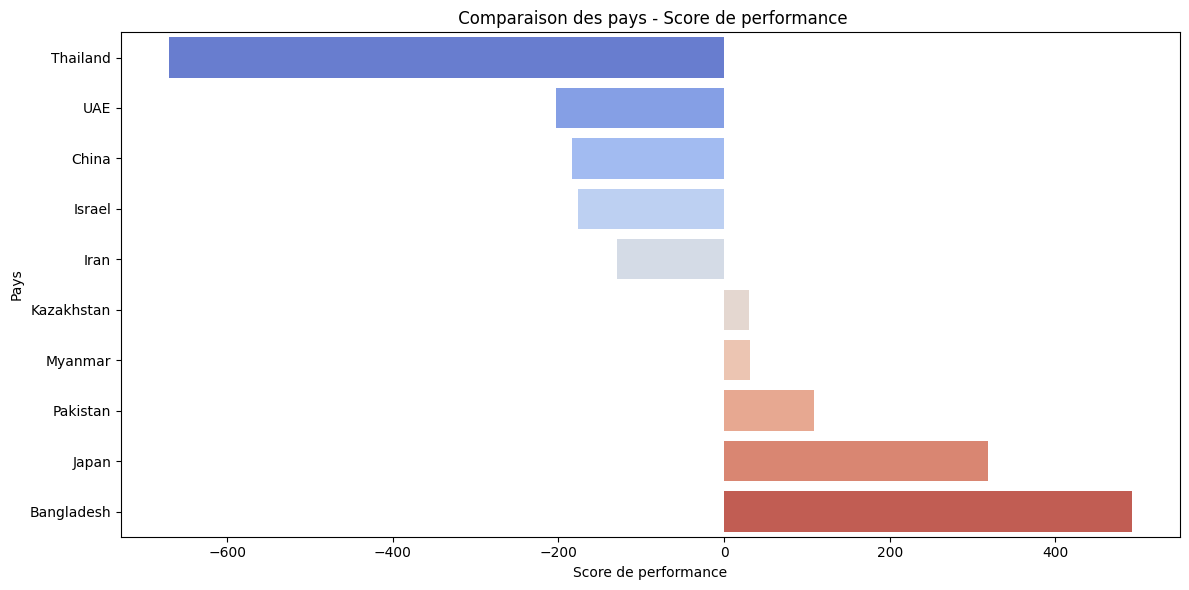

In [140]:
weights = dict(zip(weights_df['Indicator'], weights_df['Weight']))

df['PerformanceScore'] = (weights['RecoveryRate'] * df['RecoveryRate'] -weights['MortalityRate'] * df['MortalityRate'] -weights['ActiveCaseRate'] * df['ActiveCaseRate'] +weights['TestingEfficiency'] * df['TestingEfficiency'])
df['Country'] = df_wo_nan['Country']

top_5 = df.sort_values('PerformanceScore', ascending=False).head(5)
bottom_5 = df.sort_values('PerformanceScore', ascending=True).head(5)

comparison_df = pd.concat([top_5, bottom_5])
comparison_df = comparison_df.sort_values('PerformanceScore',ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='PerformanceScore', y='Country', data=comparison_df,
palette='coolwarm')
plt.title(' Comparaison des pays - Score de performance')
plt.xlabel('Score de performance')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

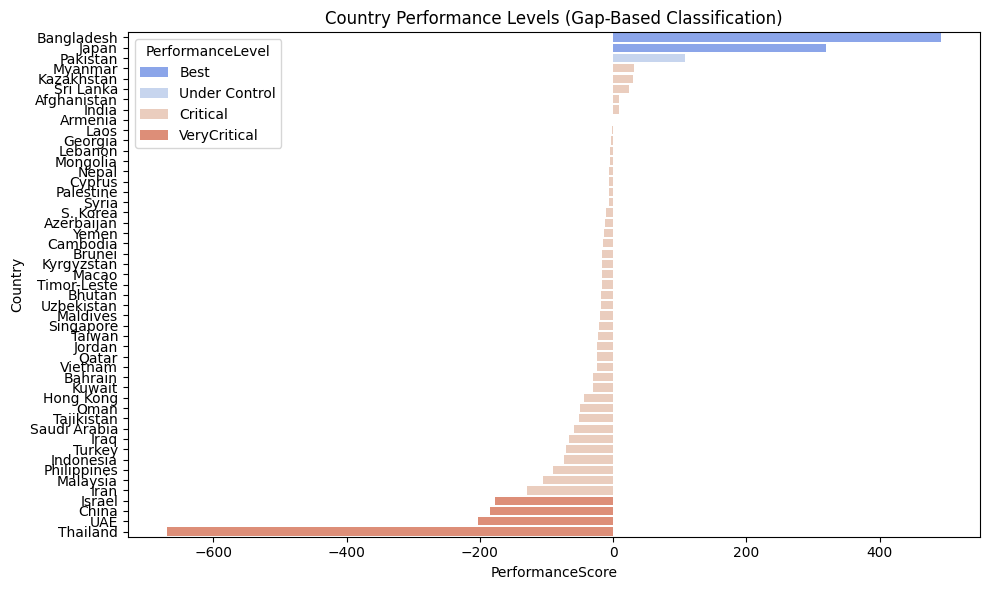

In [141]:
sorted_df = df.sort_values('PerformanceScore',
                           ascending=False).reset_index(drop=True)

sorted_df['Gap'] = sorted_df['PerformanceScore'].diff(-1).abs()

gap_threshold = 0.03 * (sorted_df['PerformanceScore'].max() -sorted_df['PerformanceScore'].min())
gap_threshold

# Identify where gap exceeds threshold
gap_indices = sorted_df.index[sorted_df['Gap'] >gap_threshold].tolist()
gap_indices

sorted_df['PerformanceLevel'] = 'Unassigned'
if len(gap_indices) >= 4:
    sorted_df.loc[:gap_indices[1], 'PerformanceLevel'] = 'Best'
    sorted_df.loc[gap_indices[1]+1:gap_indices[2], 'PerformanceLevel']= 'Under Control'
    sorted_df.loc[gap_indices[2]+1:gap_indices[3], 'PerformanceLevel']= 'Critical'
    sorted_df.loc[gap_indices[3]+1:, 'PerformanceLevel'] = 'VeryCritical'
else:
    sorted_df['PerformanceLevel'] = 'Unclassified'

plt.figure(figsize=(10, 6))
sns.barplot(data=sorted_df, x='PerformanceScore', y='Country',
hue='PerformanceLevel', dodge=False, palette='coolwarm')
plt.title('Country Performance Levels (Gap-Based Classification)')
plt.tight_layout()
plt.show()